# 📦 Case Magalu – Novo Centro de Distribuição (CD) no Nordeste

## 🎯 Cenário
O Magalu precisa abrir um novo Centro de Distribuição (CD) no Nordeste para **agilizar as entregas**.  
A diretoria está em dúvida entre duas cidades: **Recife** e **Salvador**.  

Com o apoio de **análises baseadas em dados e inteligência artificial**, buscamos responder:

- Qual das duas cidades apresenta a **localização mais estratégica** para a empresa?  
- Quais são os **principais fatores** que sustentam essa decisão?  
- Quais **ferramentas e metodologias** foram utilizadas para fundamentar o case?  

---

## 📚 Texto de Apoio 2
Para a análise, devem ser considerados os seguintes aspectos:

- 🏢 **Custos imobiliários** em ambas as cidades.  
- 🗺️ **Mapas de malha viária**, avaliando os **tempos de entrega** para as principais capitais da região.  
- 👥 **Estudo demográfico**, analisando o **potencial de consumo** nos estados vizinhos.  

---

🔎 A partir desses pontos, estruturamos o case em três etapas:  
1. **Coleta e preparação dos dados** (IBGE e fontes públicas).  
2. **Comparação quantitativa** de indicadores-chave.  
3. **Aplicação de score ponderado** para recomendar a cidade mais estratégica.  



# Instalações e Imports

In [ ]:
!pip install openrouteservice geopy folium ahpy seaborn --quiet
import pandas as pd
import matplotlib.pyplot as plt
import difflib
import re
from google.colab import files

#Upload dos arquivos
#### Aqui utilizei arquivo CSV do IBGE,
#### Sendo sobre população e renda em geral das duas cidades.

In [ ]:
data = files.upload()

Saving salvador.csv to salvador.csv
Saving recife.csv to recife.csv


In [ ]:
recife = pd.read_csv("recife.csv", sep=";")
salvador = pd.read_csv("salvador.csv", sep=";")

# Visualizando dados

In [ ]:
print("Recife:")
print(recife.head(10))

print("\nSalvador:")
print(salvador.head(10))

Recife:
  Informações por Cidades e Estados - Instituto Brasileiro de Geografia e Estatística 
0                                            Recife                                   
1  Prefeito - JOÃO HENRIQUE DE ANDRADE LIMA CAMPO...                                  
2                              Gentílico - recifense                                  
3            Área Territorial - 218,843 km²   [2024]                                  
4  População no último censo - 1.488.920 pessoas ...                                  
5  Densidade demográfica - 6.803,60 hab/km²   [2022]                                  
6    População estimada - 1.588.376 pessoas   [2025]                                  
7       Escolarização 6 a 14 anos - 97,57 %   [2022]                                  
8  IDHM Índice de desenvolvimento humano municipa...                                  
9  Mortalidade infantil - 12,32 óbitos por mil na...                                  

Salvador:
  Informações por Cidade

Agora que tenho a visualizado a estrutura, vou filtrar e funilar da forma que preciso para analise.

In [ ]:
def tabela(df, cidade):
    indicadores = []
    valores = []
    for i, row in df.iterrows():
        texto = row[0]
        if "-" in texto:
            partes = texto.split("-", 1)
            indicadores.append(partes[0].strip())
            valores.append(partes[1].strip())
    tabela = pd.DataFrame({
        "Indicador": indicadores,
        "Valor": valores
    })
    tabela.name = cidade
    return tabela

In [ ]:
tabela_recife = tabela(recife, "Recife")
tabela_salvador = tabela(salvador, "Salvador")

/tmp/ipython-input-3137231349.py:5: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  texto = row[0]


In [ ]:
print("📍 Recife")
display(tabela_recife.head())

print("\n📍 Salvador")
display(tabela_salvador.head())

📍 Recife


,Indicador,Valor
0,Prefeito,JOÃO HENRIQUE DE ANDRADE LIMA CAMPOS [2025]
1,Gentílico,recifense
2,Área Territorial,"218,843 km² [2024]"
3,População no último censo,1.488.920 pessoas [2022]
4,Densidade demográfica,"6.803,60 hab/km² [2022]"



📍 Salvador


,Indicador,Valor
0,Prefeito,BRUNO SOARES REIS [2025]
1,Gentílico,soteropolitano / salvadorense
2,Área Territorial,"692,589 km² [2024]"
3,População no último censo,2.417.678 pessoas [2022]
4,Densidade demográfica,"3.486,49 hab/km² [2022]"


# Criando Indicadores

In [ ]:
indicadores_chave = [
    "População estimada", # Mais pessoas = maior demanda de compras.
    "Densidade demográfica", # Mais concentrada = mais fácil distribuir
    "Área Territorial", # Cidades grandes = aumentar o tempo de entrega (maleficio)
    "IDHM" # IDHM alto = melhor infraestrutura
]

In [ ]:
def filtrar_indicadores(tabela, indicadores):
    return tabela[tabela['Indicador'].str.contains('|'.join(indicadores), case=False, na=False)]

In [ ]:
recife_filtrado = filtrar_indicadores(tabela_recife, indicadores_chave)
salvador_filtrado = filtrar_indicadores(tabela_salvador, indicadores_chave)


In [ ]:

print("📍 Recife")
display(recife_filtrado)

print("\n📍 Salvador")
display(salvador_filtrado)

📍 Recife


,Indicador,Valor
2,Área Territorial,"218,843 km² [2024]"
4,Densidade demográfica,"6.803,60 hab/km² [2022]"
5,População estimada,1.588.376 pessoas [2025]
7,IDHM Índice de desenvolvimento humano municipal,"0,772 [2010]"
13,Densidade demográfica: Censo 2022: População e...,Primeiros Resultados - Atualizado em 22/12/2023
14,IDHM Índice de desenvolvimento humano municipa...,PNUD



📍 Salvador


,Indicador,Valor
2,Área Territorial,"692,589 km² [2024]"
4,Densidade demográfica,"3.486,49 hab/km² [2022]"
5,População estimada,2.564.204 pessoas [2025]
7,IDHM Índice de desenvolvimento humano municipal,"0,759 [2010]"
13,Densidade demográfica: Censo 2022: População e...,Primeiros Resultados - Atualizado em 22/12/2023
14,IDHM Índice de desenvolvimento humano municipa...,PNUD


In [ ]:
comparativo = pd.merge(
    recife_filtrado,
    salvador_filtrado,
    on="Indicador",
    suffixes=("_Recife", "_Salvador")
)

display(comparativo)

,Indicador,Valor_Recife,Valor_Salvador
0,Área Territorial,"218,843 km² [2024]","692,589 km² [2024]"
1,Densidade demográfica,"6.803,60 hab/km² [2022]","3.486,49 hab/km² [2022]"
2,População estimada,1.588.376 pessoas [2025],2.564.204 pessoas [2025]
3,IDHM Índice de desenvolvimento humano municipal,"0,772 [2010]","0,759 [2010]"
4,Densidade demográfica: Censo 2022: População e...,Primeiros Resultados - Atualizado em 22/12/2023,Primeiros Resultados - Atualizado em 22/12/2023
5,IDHM Índice de desenvolvimento humano municipa...,PNUD,PNUD


# Comparativo descritivo por indices

In [ ]:
#transformar em número
def limpar_valor(valor):
    if isinstance(valor, str):
        valor = re.sub(r"\[.*?\]", "", valor)
        valor = valor.replace("hab/km²","").replace("pessoas","").replace("km²","")
        valor = valor.replace(".", "").replace(",", ".")
        valor = valor.strip()
        try:
            return float(valor)
        except:
            return None
    return valor

In [ ]:
comparativo['Recife_num'] = comparativo['Valor_Recife'].apply(limpar_valor)
comparativo['Salvador_num'] = comparativo['Valor_Salvador'].apply(limpar_valor)

In [ ]:
display(comparativo[['Indicador', 'Valor_Recife', 'Valor_Salvador', 'Recife_num', 'Salvador_num']])

,Indicador,Valor_Recife,Valor_Salvador,Recife_num,Salvador_num
0,Área Territorial,"218,843 km² [2024]","692,589 km² [2024]",218.843,692.589
1,Densidade demográfica,"6.803,60 hab/km² [2022]","3.486,49 hab/km² [2022]",6803.600,3486.490
2,População estimada,1.588.376 pessoas [2025],2.564.204 pessoas [2025],1588376.000,2564204.000
3,IDHM Índice de desenvolvimento humano municipal,"0,772 [2010]","0,759 [2010]",0.772,0.759
4,Densidade demográfica: Censo 2022: População e...,Primeiros Resultados - Atualizado em 22/12/2023,Primeiros Resultados - Atualizado em 22/12/2023,NaN,NaN
5,IDHM Índice de desenvolvimento humano municipa...,PNUD,PNUD,NaN,NaN


Criando um score

In [ ]:
pesos = {
    "População estimada": 0.3, # Quanto maior a população, maior o potencial de demanda de produtos
    "Densidade demográfica": 0.3, # Alta densidade = pessoas mais concentradas = logística de distribuição mais eficiente
    "Área Territorial": -0.2,  # negativo pq atrapalha na logística
    "IDHM": 0.2 # cidade com IDHM mais alto tende a ter mais consumidores
}

In [ ]:
def calcular_score(linha, cidade):
    indicador = linha['Indicador']
    peso = pesos.get(indicador, 0)
    return linha[f'{cidade}_num'] * peso

In [ ]:

comparativo['Score_Recife'] = comparativo.apply(lambda x: calcular_score(x, 'Recife'), axis=1)
comparativo['Score_Salvador'] = comparativo.apply(lambda x: calcular_score(x, 'Salvador'), axis=1)


score final

In [ ]:
score_final = {
    "Recife": comparativo['Score_Recife'].sum(),
    "Salvador": comparativo['Score_Salvador'].sum()
}

In [ ]:
print("📊 Score final:", score_final)

📊 Score final: {'Recife': np.float64(478510.1114), 'Salvador': np.float64(770168.6292)}


Grafico

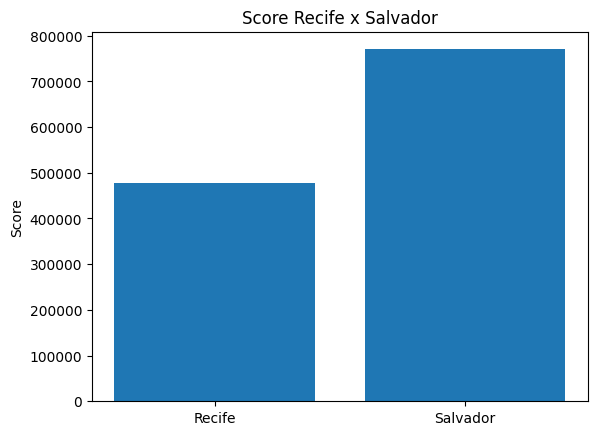

In [ ]:
plt.bar(score_final.keys(), score_final.values())
plt.title("Score Recife x Salvador")
plt.ylabel("Score")
plt.show()


# Custos imobiliarios

como não achei base de dados para imóveis, pensei em fazer com uma base de 10 anuncios cada cidade.

In [ ]:
# Criando tabela com 10 casos para cada cidade
cidades = ["Recife"]*10 + ["Salvador"]*10

localizacoes = [
    # Recife
    "Avenida Prefeito Antônio Pereira, Curado",
    "Mascaranhas de Morais 4759, Imbiribeira",
    "Estrada dos Remédios 1462, Ilha do Retiro",
    "Rua do Brum 261",
    "Rua José Álvaro de Melo 355.B, Imbiribeira",
    "Av Barão de Bonito, Várzea",
    "Rua Doutor Gonzaga Maranhão 321, Ipsep",
    "Rua Claudino dos Santos, Afogados",
    "Rua Fernando de Noronha 135, Várzea",
    "Endereço não informado, Santo Amaro",
    # Salvador
    "Rua da Nigéria 300, Granjas Rurais Presidente Vargas",
    "Rua Monte Alverne 108, Fazenda Coutos",
    "Rua do Luxemburgo 0, Granjas Rurais Presidente Vargas",
    "Avenida Beira Mar 344, Ribeira",
    "Endereço não informado, Cassange",
    "Avenida Estados Unidos 850, Comércio",
    "Travessa 2 de Julho, São Cristóvão",
    "Rua Dr. Altino Teixeira, Porto Seco Pirajá",
    "Rua Marcelino Garrido 378-E, Valéria",
    "Rua Paraná 287, Paripe"
]


areas = [
    # Recife
    4000, 360, 10150, 750, 300, 794, 243, 1500, 363, 750,
    # Salvador
    2065, 1600, 5600, 1400, 20000, 627, 600, 3695, 450, 360
]


precos_m2 = [
    # Recife
    8000000, 1400000, 38000000, 1500000, 1100000, 2500000, 495000, 3600000, 1100000, 2000000,
    # Salvador
    3400000, 1100000, 9000000, 3500000, 4000000, 1800000, 1100000, 4500000, 200000, 700000
]


tabela_custo = pd.DataFrame({
    "Cidade": cidades,
    "Localização": localizacoes,
    "Área_m2": areas,
    "Preço_total_R$": precos_m2
})

display(tabela_custo)


,Cidade,Localização,Área_m2,Preço_total_R$
0,Recife,"Avenida Prefeito Antônio Pereira, Curado",4000,8000000
1,Recife,"Mascaranhas de Morais 4759, Imbiribeira",360,1400000
2,Recife,"Estrada dos Remédios 1462, Ilha do Retiro",10150,38000000
3,Recife,Rua do Brum 261,750,1500000
4,Recife,"Rua José Álvaro de Melo 355.B, Imbiribeira",300,1100000
5,Recife,"Av Barão de Bonito, Várzea",794,2500000
6,Recife,"Rua Doutor Gonzaga Maranhão 321, Ipsep",243,495000
7,Recife,"Rua Claudino dos Santos, Afogados",1500,3600000
8,Recife,"Rua Fernando de Noronha 135, Várzea",363,1100000
9,Recife,"Endereço não informado, Santo Amaro",750,2000000


In [ ]:
tabela_custo["Preço_m2"] = tabela_custo["Preço_total_R$"] / tabela_custo["Área_m2"]

In [ ]:
# Estatísticas gerais
estatisticas = tabela_custo.groupby("Cidade")[["Área_m2", "Preço_total_R$", "Preço_m2"]].describe()
display(estatisticas)

Área_m2                                                              \
           count    mean         std    min     25%     50%     75%      max   
Cidade                                                                         
Recife      10.0  1921.0  3100.82326  243.0  360.75   750.0  1323.5  10150.0   
Salvador    10.0  3639.7  5985.24406  360.0  606.75  1500.0  3287.5  20000.0   

         Preço_total_R$             ...                        Preço_m2  \
                  count       mean  ...        75%         max    count   
Cidade                              ...                                   
Recife             10.0  5969500.0  ...  3325000.0  38000000.0     10.0   
Salvador           10.0  2930000.0  ...  3875000.0   9000000.0     10.0   

                                                                     \
                 mean         std     min          25%          50%   
Cidade                                                                
Recife    2858.201926  745.968109  2000.0  2127.777778  2848.484848   
Salvador  1495.202956  866.950948   200.0   820.090494  1626.815981   

                                    
                  75%          max  
Cidade                              
Recife    3537.153652  3888.888889  
Salvador  1916.666667  2870.813397  

[2 rows x 24 columns]

Salvador apresenta imóveis em geral maiores que Recife, mas ambos os mercados possuem grande dispersão de áreas. Recife tem imóveis com valores extremos muito altos, enquanto Salvador tem imóveis mais concentrados em torno da mediana. Em termos de preço por m², Recife é mais caro e estável, enquanto Salvador apresenta imóveis mais baratos, porém com maior dispersão de preços por metro quadrado. O que indica que Salvador é mais custo-beneficio.

In [ ]:
#Aqui calculei a media de preços na cidade isolado
preco_medio = tabela_custo.groupby("Cidade")["Preço_m2"].mean()
area_media = tabela_custo.groupby("Cidade")["Área_m2"].mean()

print(preco_medio)
print(area_media)


Cidade
Recife      2858.201926
Salvador    1495.202956
Name: Preço_m2, dtype: float64
Cidade
Recife      1921.0
Salvador    3639.7
Name: Área_m2, dtype: float64


Mostra que Recife tem custo por m² quase o dobro de Salvador mas que os imóveis em Salvador são em média quase o dobro do tamanho dos de Recife.

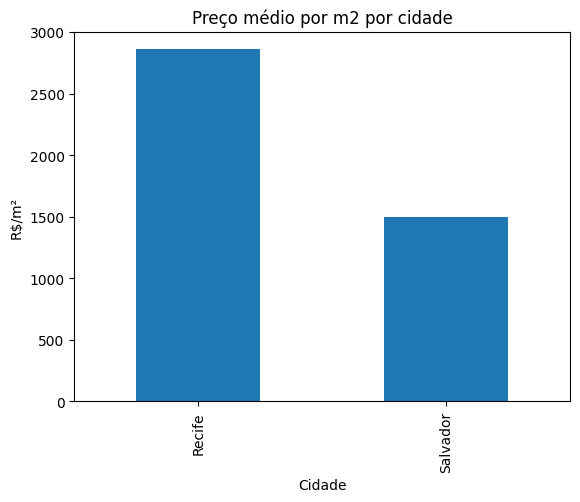

In [ ]:
preco_medio.plot(kind="bar", title="Preço médio por m2 por cidade")
plt.ylabel("R$/m²")
plt.show()

In [ ]:
#Bairros mais caros para mais baratos
bairro_valorizado = tabela_custo.groupby(["Cidade", "Localização"])["Preço_m2"].mean().sort_values(ascending=False)
display(bairro_valorizado)

Cidade    Localização                                          
Recife    Mascaranhas de Morais 4759, Imbiribeira                  3888.888889
          Estrada dos Remédios 1462, Ilha do Retiro                3743.842365
          Rua José Álvaro de Melo 355.B, Imbiribeira               3666.666667
          Av Barão de Bonito, Várzea                               3148.614610
          Rua Fernando de Noronha 135, Várzea                      3030.303030
Salvador  Avenida Estados Unidos 850, Comércio                     2870.813397
Recife    Endereço não informado, Santo Amaro                      2666.666667
Salvador  Avenida Beira Mar 344, Ribeira                           2500.000000
Recife    Rua Claudino dos Santos, Afogados                        2400.000000
          Rua Doutor Gonzaga Maranhão 321, Ipsep                   2037.037037
          Avenida Prefeito Antônio Pereira, Curado                 2000.000000
          Rua do Brum 261                                          2000.000000
Salvador  Rua Paraná 287, Paripe                                   1944.444444
          Travessa 2 de Julho, São Cristóvão                       1833.333333
          Rua da Nigéria 300, Granjas Rurais Presidente Vargas     1646.489104
          Rua do Luxemburgo 0, Granjas Rurais Presidente Vargas    1607.142857
          Rua Dr. Altino Teixeira, Porto Seco Pirajá               1217.861976
          Rua Monte Alverne 108, Fazenda Coutos                     687.500000
          Rua Marcelino Garrido 378-E, Valéria                      444.444444
          Endereço não informado, Cassange                          200.000000
Name: Preço_m2, dtype: float64

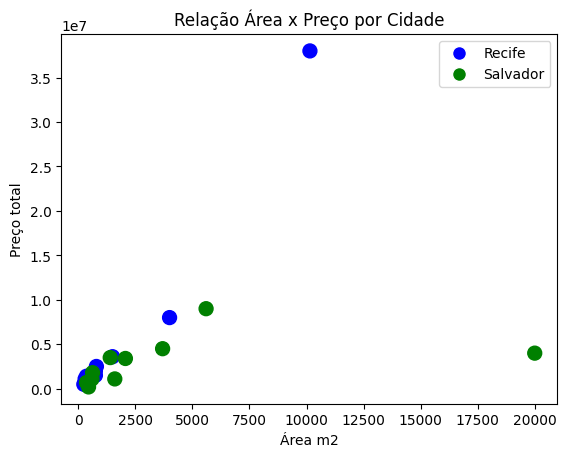

In [ ]:
cores = {"Recife": "blue", "Salvador": "green"}
tabela_custo["cor"] = tabela_custo["Cidade"].map(cores)

plt.scatter(
    tabela_custo["Área_m2"],
    tabela_custo["Preço_total_R$"],
    c=tabela_custo["cor"],
    s=100
)
plt.xlabel("Área m2")
plt.ylabel("Preço total")
plt.title("Relação Área x Preço por Cidade")
plt.legend(handles=[
    plt.Line2D([0], [0], marker='o', color='w', label='Recife', markerfacecolor='blue', markersize=10),
    plt.Line2D([0], [0], marker='o', color='w', label='Salvador', markerfacecolor='green', markersize=10)
])
plt.show()

In [ ]:
top5 = tabela_custo.groupby("Cidade").apply(lambda x: x.nlargest(5, "Preço_m2"))
display(top5)

/tmp/ipython-input-2910775257.py:1: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  top5 = tabela_custo.groupby("Cidade").apply(lambda x: x.nlargest(5, "Preço_m2"))


Cidade                                        Localização  \
Cidade                                                                     
Recife   1     Recife            Mascaranhas de Morais 4759, Imbiribeira   
         2     Recife          Estrada dos Remédios 1462, Ilha do Retiro   
         4     Recife         Rua José Álvaro de Melo 355.B, Imbiribeira   
         5     Recife                         Av Barão de Bonito, Várzea   
         8     Recife                Rua Fernando de Noronha 135, Várzea   
Salvador 15  Salvador               Avenida Estados Unidos 850, Comércio   
         13  Salvador                     Avenida Beira Mar 344, Ribeira   
         19  Salvador                             Rua Paraná 287, Paripe   
         16  Salvador                 Travessa 2 de Julho, São Cristóvão   
         10  Salvador  Rua da Nigéria 300, Granjas Rurais Presidente ...   

             Área_m2  Preço_total_R$     Preço_m2    cor  
Cidade                                                    
Recife   1       360         1400000  3888.888889   blue  
         2     10150        38000000  3743.842365   blue  
         4       300         1100000  3666.666667   blue  
         5       794         2500000  3148.614610   blue  
         8       363         1100000  3030.303030   blue  
Salvador 15      627         1800000  2870.813397  green  
         13     1400         3500000  2500.000000  green  
         19      360          700000  1944.444444  green  
         16      600         1100000  1833.333333  green  
         10     2065         3400000  1646.489104  green

Salvador continua em melhor custo beneficio

# Logistica

Definindo pontos de interesse, capitais vizinhas para análise logística:
- **Recife**: João Pessoa, Maceió, Fortaleza, Aracaju
- **Salvador**: Aracaju, Maceió, João Pessoa

In [ ]:
# Peguei tempos pelo maps e prefiri criar manualmente
tempo_entrega = {
    "Recife": {"João Pessoa": 2, "Maceió": 4, "Fortaleza": 11, "Aracaju": 7},
    "Salvador": {"João Pessoa": 11, "Maceió": 8, "Fortaleza": 20, "Aracaju": 5}
}

tabela_logistica = pd.DataFrame({
    "Cidade": ["Recife", "Salvador"],
    "Área média (m²)": [area_media["Recife"], area_media["Salvador"]],
    "Preço médio m² (R$)": [preco_m2["Recife"], preco_m2["Salvador"]],
    "Tempo médio João Pessoa (h)": [tempo_entrega["Recife"]["João Pessoa"], tempo_entrega["Salvador"]["João Pessoa"]],
    "Tempo médio Maceió (h)": [tempo_entrega["Recife"]["Maceió"], tempo_entrega["Salvador"]["Maceió"]],
    "Tempo médio Fortaleza (h)": [tempo_entrega["Recife"]["Fortaleza"], tempo_entrega["Salvador"]["Fortaleza"]],
    "Tempo médio Aracaju (h)": [tempo_entrega["Recife"]["Aracaju"], tempo_entrega["Salvador"]["Aracaju"]],
})

display(tabela_logistica)

,Cidade,Área média (m²),Preço médio m² (R$),Tempo médio João Pessoa (h),Tempo médio Maceió (h),Tempo médio Fortaleza (h),Tempo médio Aracaju (h)
0,Recife,1921.0,2858.2,2,4,11,7
1,Salvador,3639.7,1495.2,11,8,20,5


Recife pode ter galpões menores, mais caros por m2, mas logística mais rápida para norte e leste.
Salvador tem galpões maiores e mais baratos por m2, logística melhor para sul.

# **Resultado**


## Principais fatores finalizando

1. **Maior potencial de consumo:**  
   Salvador apresenta uma população estimada maior que Recife, o que representa um mercado consumidor maior para o Magalu.

2. **Custo-benefício imobiliário:**  
   Embora a análise de custos tenha sido baseada em uma base manual de dados, Salvador demonstrou ter um preço médio por m2 menor do que Recife, mesmo com imóveis de área média maior. Isso mostra que é possível adquirir ou alugar espaços maiores por um custo mais acessível em Salvador.

3. **Score Ponderado:**  
   A aplicação do score ponderado considerou a importância de cada indicador, resultando em um score final maior para Salvador, reforçando sua posição como a cidade mais estratégica.

Apesar de Recife apresentar vantagens em **densidade demográfica** o que é otimo para a logística de entrega em áreas mais concentradas e **tempos de entrega mais rápidos** para algumas capitais como João Pessoa e Fortaleza, o **maior potencial de mercado** e o **custo-benefício imobiliário** de Salvador tornam a opção mais estratégica para o Magalu expandir sua operação no Nordeste.


---


**Salvador se mostra como a escolha mais vantajosa.**


---



# Apresentação do Estudo

Para agilizar as entregas do Magalu no Nordeste, fui analisar pra recomendar o melhor município. Iniciei o estudo coletando dados do IBGE sobre população e renda das duas cidades, tratando para extrair indicadores chave como população estimada, densidade demográfica, área territorial e IDHM. Realizei uma comparação quantitativa desses indicadores e apliquei um score ponderado, atribuindo pesos de acordo com a relevância para a logística e potencial de mercado.

Em seguida, analisei os custos imobiliários, criando uma base manual com dados de anúncios para comparar o preço médio por m2 em ambas as cidades. Também considerei a logística, comparando os tempos de entrega estimados para capitais vizinhas a partir de Recife e Salvador.

Com base na análise demográfica e no score ponderado, que indicaram um maior potencial de mercado para Salvador, e considerando o custo-benefício imobiliário favorável, cheguei à conclusão de que Salvador se apresenta como a escolha mais estratégica para o novo CD.

Apesar de Recife ter vantagens em densidade demográfica e tempos de entrega para algumas regiões, o potencial de consumo e os custos imobiliários de Salvador a tornam a opção mais vantajosa para o Magalu.

**Portanto, minha recomendação é que o novo Centro de Distribuição do Magalu no Nordeste seja instalado em Salvador.**